In [2]:
# Load 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [3]:
bikes = pd.read_csv("day.csv")

In [4]:
bikes.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [5]:
bikes = bikes.drop(["dteday","casual","registered"], axis=1)

In [6]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   season      730 non-null    int64  
 2   yr          730 non-null    int64  
 3   mnth        730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int64  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    int64  
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  cnt         730 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 74.3 KB


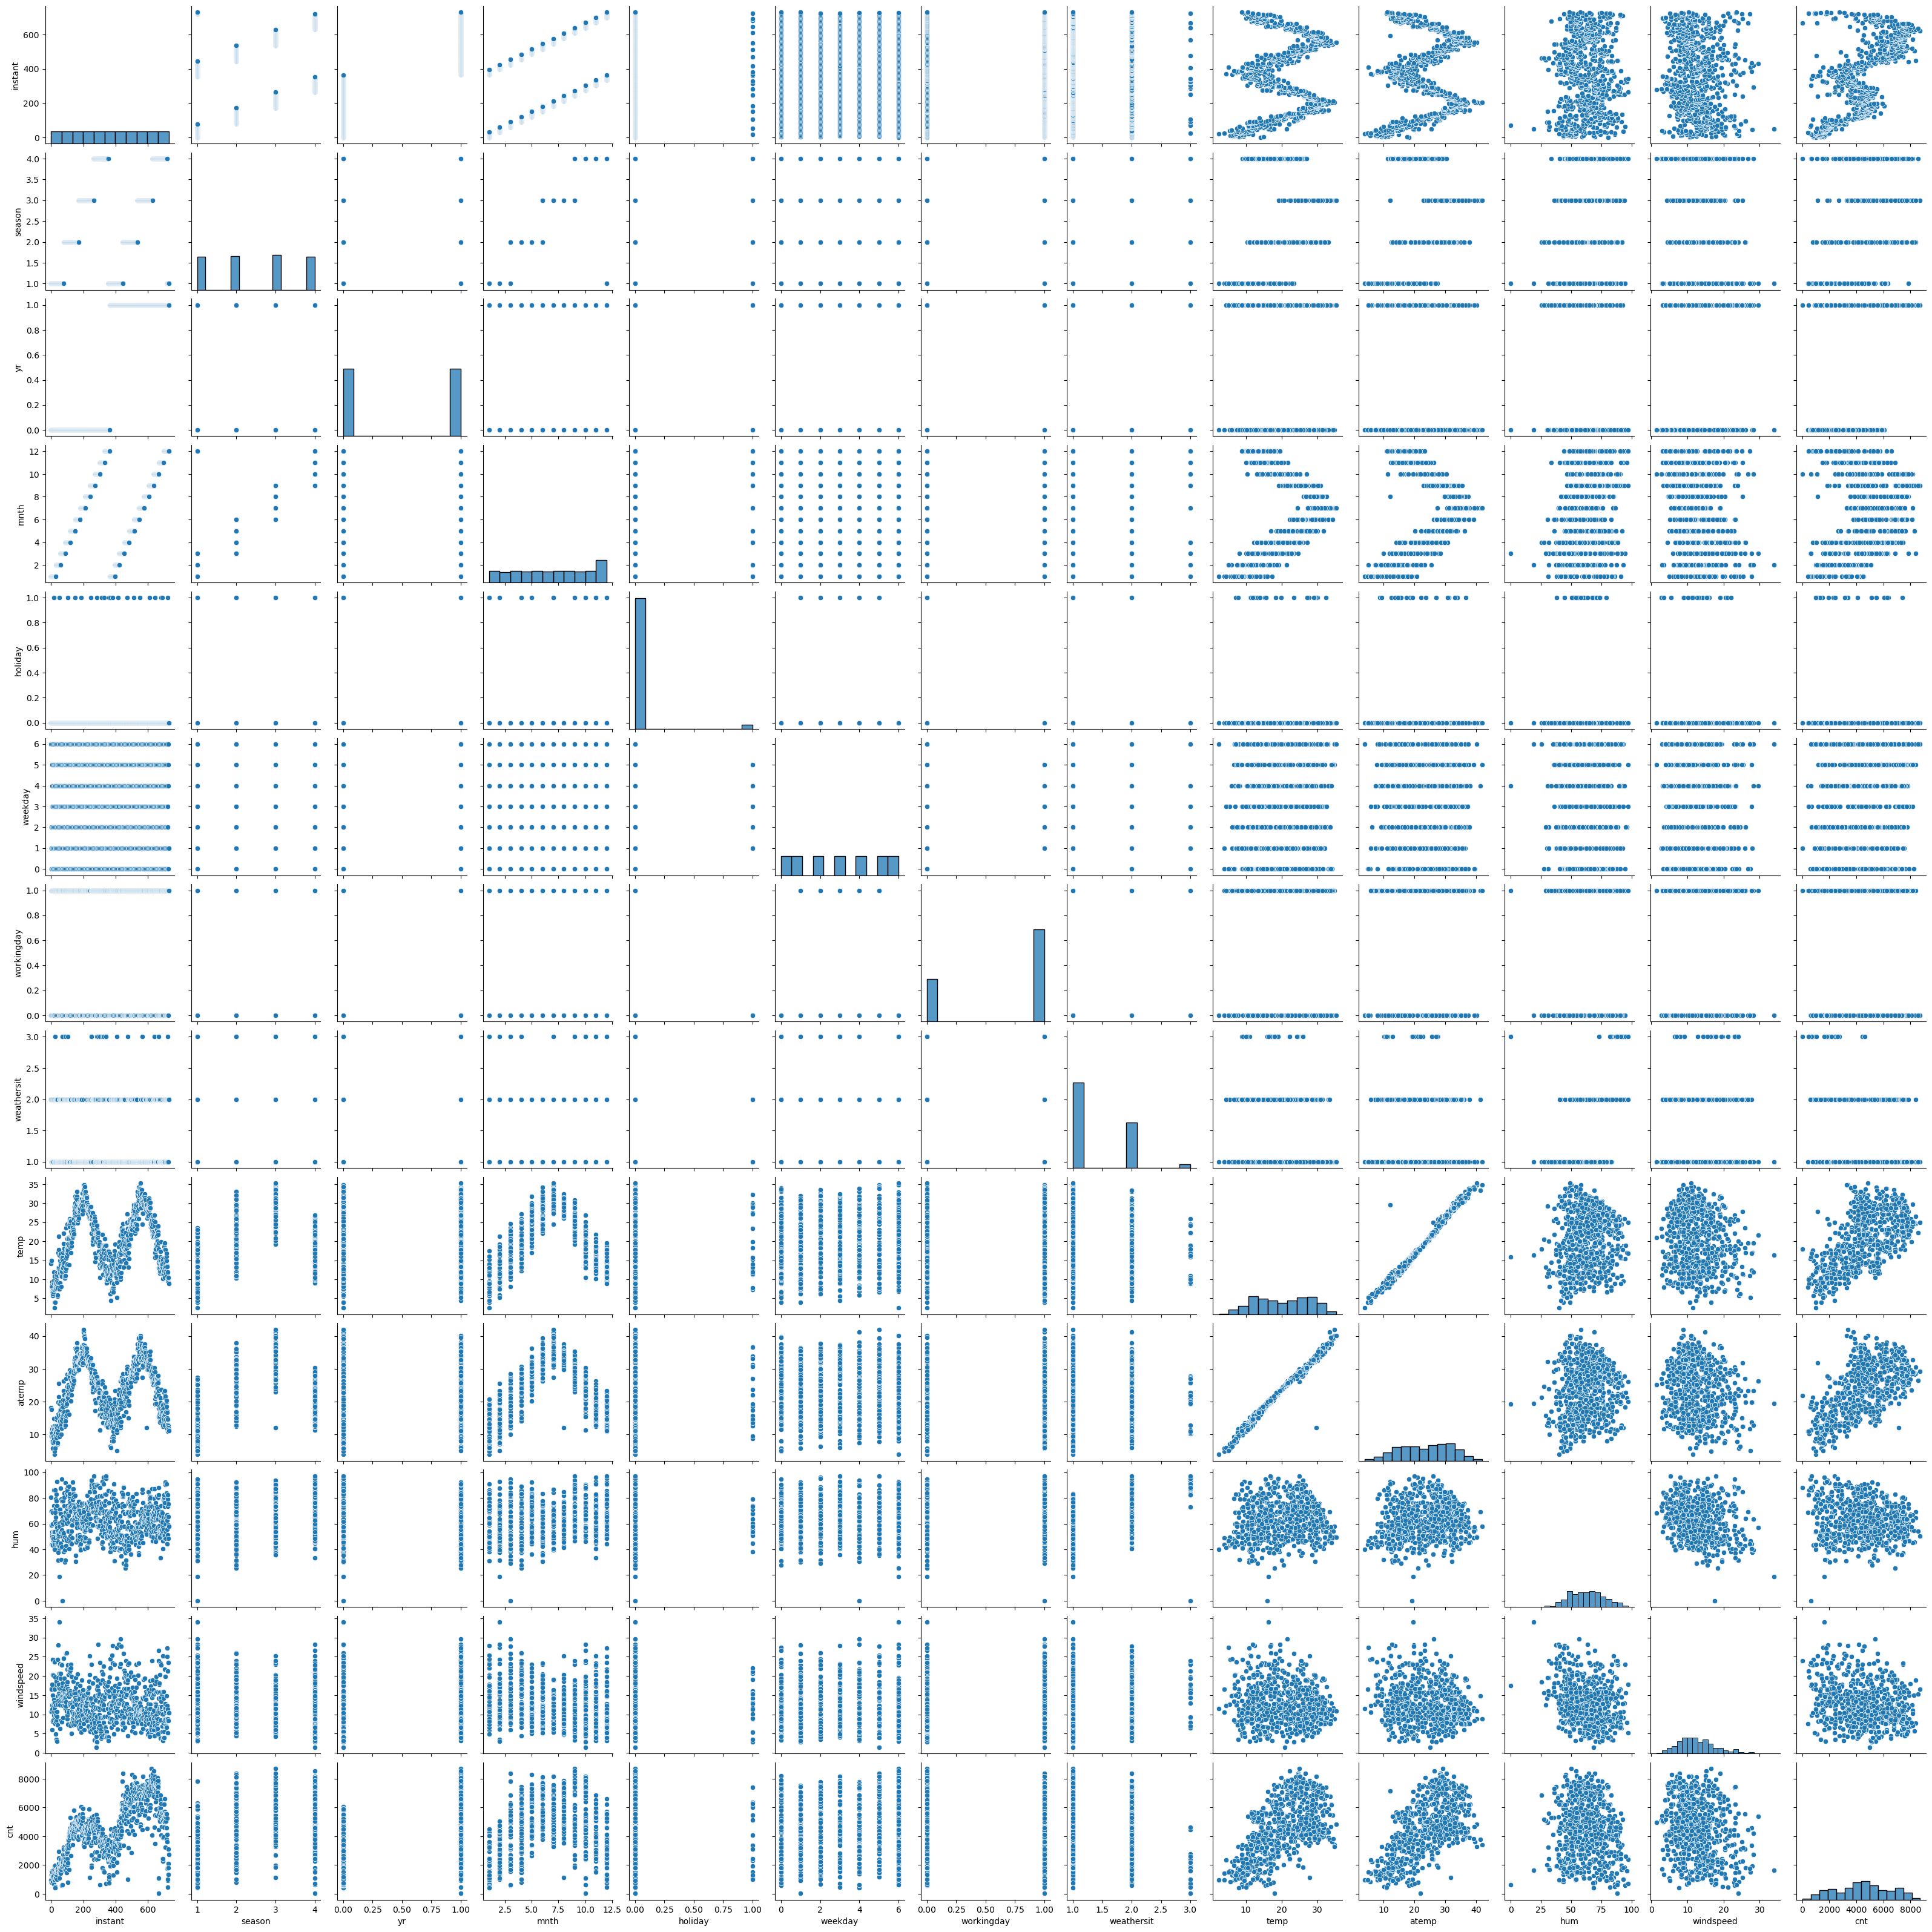

In [7]:

sns.pairplot(bikes)
plt.show()

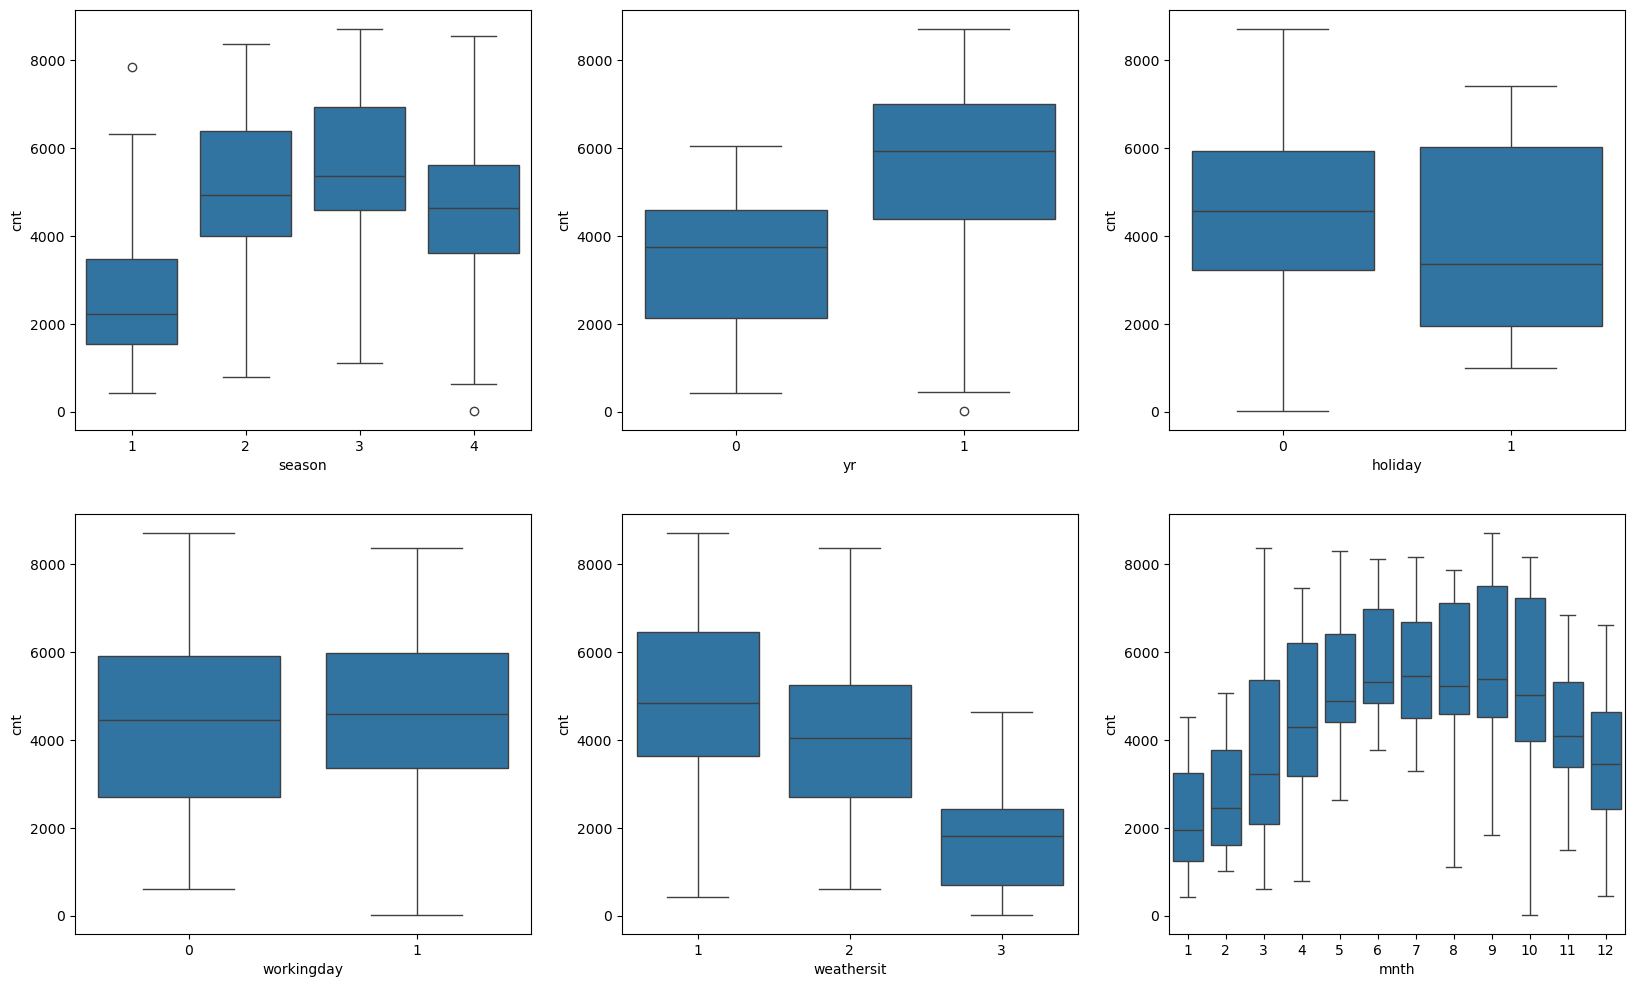

In [8]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = bikes)
plt.subplot(2,3,2)
sns.boxplot(x = 'yr', y = 'cnt', data = bikes)
plt.subplot(2,3,3)
sns.boxplot(x = 'holiday', y = 'cnt', data = bikes)
plt.subplot(2,3,4)
sns.boxplot(x = 'workingday', y = 'cnt', data = bikes)
plt.subplot(2,3,5)
sns.boxplot(x = 'weathersit', y = 'cnt', data = bikes)
plt.subplot(2,3,6)
sns.boxplot(x = 'mnth', y = 'cnt', data = bikes)
plt.show()

In [9]:
bikes['season'] = bikes['season'].map({1:"spring", 2:"summer", 3:"fall", 4:"winter"})
seasons =  pd.get_dummies(bikes['season'], drop_first=True)

In [10]:
seasons.head()

,spring,summer,winter
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [11]:
bikes = pd.concat([bikes, seasons], axis=1)

In [12]:
bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,spring,summer,winter
0,1,spring,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985,True,False,False
1,2,spring,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801,True,False,False
2,3,spring,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349,True,False,False
3,4,spring,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562,True,False,False
4,5,spring,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600,True,False,False


In [13]:
weathersit_map = {1: "Clear",2: "Mist",3: "Light Snow",4: "Heavy Rain"}

In [14]:
bikes["weathersit"] = bikes["weathersit"].map(weathersit_map)

In [15]:
bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,spring,summer,winter
0,1,spring,0,1,0,6,0,Mist,14.110847,18.18125,80.5833,10.749882,985,True,False,False
1,2,spring,0,1,0,0,0,Mist,14.902598,17.68695,69.6087,16.652113,801,True,False,False
2,3,spring,0,1,0,1,1,Clear,8.050924,9.47025,43.7273,16.636703,1349,True,False,False
3,4,spring,0,1,0,2,1,Clear,8.200000,10.60610,59.0435,10.739832,1562,True,False,False
4,5,spring,0,1,0,3,1,Clear,9.305237,11.46350,43.6957,12.522300,1600,True,False,False


In [16]:
weathersit = pd.get_dummies(bikes['weathersit'], drop_first=True)

In [17]:
weathersit.head()

,Light Snow,Mist
0,False,True
1,False,True
2,False,False
3,False,False
4,False,False


In [18]:
bikes = pd.concat([bikes, weathersit], axis=1)

In [19]:
bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,spring,summer,winter,Light Snow,Mist
0,1,spring,0,1,0,6,0,Mist,14.110847,18.18125,80.5833,10.749882,985,True,False,False,False,True
1,2,spring,0,1,0,0,0,Mist,14.902598,17.68695,69.6087,16.652113,801,True,False,False,False,True
2,3,spring,0,1,0,1,1,Clear,8.050924,9.47025,43.7273,16.636703,1349,True,False,False,False,False
3,4,spring,0,1,0,2,1,Clear,8.200000,10.60610,59.0435,10.739832,1562,True,False,False,False,False
4,5,spring,0,1,0,3,1,Clear,9.305237,11.46350,43.6957,12.522300,1600,True,False,False,False,False


In [20]:
bikes["weekday"] = bikes["weekday"].map({0:"Sunday",1:"Monday",2:"Tuesday",3:"Wednesday",4:"Thrusday",5:"Friday",6:"Saturday"})
weekday = pd.get_dummies(bikes['weekday'], drop_first=True)

In [21]:
weekday.head()

,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
0,False,True,False,False,False,False
1,False,False,True,False,False,False
2,True,False,False,False,False,False
3,False,False,False,False,True,False
4,False,False,False,False,False,True


In [22]:
bikes = pd.concat([bikes, weekday], axis=1)

In [23]:
bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
0,1,spring,0,1,0,Saturday,0,Mist,14.110847,18.18125,...,False,False,False,True,False,True,False,False,False,False
1,2,spring,0,1,0,Sunday,0,Mist,14.902598,17.68695,...,False,False,False,True,False,False,True,False,False,False
2,3,spring,0,1,0,Monday,1,Clear,8.050924,9.47025,...,False,False,False,False,True,False,False,False,False,False
3,4,spring,0,1,0,Tuesday,1,Clear,8.200000,10.60610,...,False,False,False,False,False,False,False,False,True,False
4,5,spring,0,1,0,Wednesday,1,Clear,9.305237,11.46350,...,False,False,False,False,False,False,False,False,False,True


In [24]:
bikes.columns

Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'spring',
       'summer', 'winter', 'Light Snow', 'Mist', 'Monday', 'Saturday',
       'Sunday', 'Thrusday', 'Tuesday', 'Wednesday'],
      dtype='object')

In [25]:
var_list = ['spring','summer', 'winter', 'Light Snow', 'Mist', 'Monday', 'Saturday','Sunday', 'Thrusday', 'Tuesday', 'Wednesday']

bikes[var_list] = bikes[var_list].apply(lambda x: x.map({True:1, False:0}))

In [26]:
bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
0,1,spring,0,1,0,Saturday,0,Mist,14.110847,18.18125,...,0,0,0,1,0,1,0,0,0,0
1,2,spring,0,1,0,Sunday,0,Mist,14.902598,17.68695,...,0,0,0,1,0,0,1,0,0,0
2,3,spring,0,1,0,Monday,1,Clear,8.050924,9.47025,...,0,0,0,0,1,0,0,0,0,0
3,4,spring,0,1,0,Tuesday,1,Clear,8.200000,10.60610,...,0,0,0,0,0,0,0,0,1,0
4,5,spring,0,1,0,Wednesday,1,Clear,9.305237,11.46350,...,0,0,0,0,0,0,0,0,0,1


In [27]:
bikes = bikes.drop(["season", "weekday","weathersit"], axis=1)

In [28]:
bikes.head()

,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
0,1,0,1,0,0,14.110847,18.18125,80.5833,10.749882,985,...,0,0,0,1,0,1,0,0,0,0
1,2,0,1,0,0,14.902598,17.68695,69.6087,16.652113,801,...,0,0,0,1,0,0,1,0,0,0
2,3,0,1,0,1,8.050924,9.47025,43.7273,16.636703,1349,...,0,0,0,0,1,0,0,0,0,0
3,4,0,1,0,1,8.200000,10.60610,59.0435,10.739832,1562,...,0,0,0,0,0,0,0,0,1,0
4,5,0,1,0,1,9.305237,11.46350,43.6957,12.522300,1600,...,0,0,0,0,0,0,0,0,0,1


In [29]:
bikes.columns

Index(['instant', 'yr', 'mnth', 'holiday', 'workingday', 'temp', 'atemp',
       'hum', 'windspeed', 'cnt', 'spring', 'summer', 'winter', 'Light Snow',
       'Mist', 'Monday', 'Saturday', 'Sunday', 'Thrusday', 'Tuesday',
       'Wednesday'],
      dtype='object')

In [30]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   yr          730 non-null    int64  
 2   mnth        730 non-null    int64  
 3   holiday     730 non-null    int64  
 4   workingday  730 non-null    int64  
 5   temp        730 non-null    float64
 6   atemp       730 non-null    float64
 7   hum         730 non-null    float64
 8   windspeed   730 non-null    float64
 9   cnt         730 non-null    int64  
 10  spring      730 non-null    int64  
 11  summer      730 non-null    int64  
 12  winter      730 non-null    int64  
 13  Light Snow  730 non-null    int64  
 14  Mist        730 non-null    int64  
 15  Monday      730 non-null    int64  
 16  Saturday    730 non-null    int64  
 17  Sunday      730 non-null    int64  
 18  Thrusday    730 non-null    int64  
 19  Tuesday     730 non-null    i

In [31]:
df_train, df_test = train_test_split(bikes)

df_train.shape,df_test.shape,

((547, 21), (183, 21))

In [32]:
scaler = MinMaxScaler()

num_varlist = ["temp","atemp","hum","windspeed","cnt","instant"]

df_train[num_varlist] = scaler.fit_transform(df_train[num_varlist])

In [33]:
df_train.head()

,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
171,0.234568,0,6,0,1,0.774672,0.733207,0.792203,0.322399,0.553728,...,0,0,0,1,0,0,0,0,1,0
207,0.283951,0,7,0,1,0.892009,0.802804,0.414311,0.353552,0.533134,...,0,0,0,0,0,0,0,0,0,1
365,0.500686,1,1,0,0,0.387359,0.389264,0.712082,0.375353,0.261390,...,0,0,0,0,0,0,1,0,0,0
459,0.629630,1,4,0,1,0.468352,0.462170,0.384748,0.443885,0.740336,...,1,0,0,0,0,0,0,1,0,0
710,0.973937,1,12,0,1,0.297020,0.286507,0.553556,0.302142,0.609411,...,0,1,0,1,0,0,0,0,0,1


In [34]:
df_train.columns

Index(['instant', 'yr', 'mnth', 'holiday', 'workingday', 'temp', 'atemp',
       'hum', 'windspeed', 'cnt', 'spring', 'summer', 'winter', 'Light Snow',
       'Mist', 'Monday', 'Saturday', 'Sunday', 'Thrusday', 'Tuesday',
       'Wednesday'],
      dtype='object')

In [35]:
y_train = df_train.pop("cnt")

X_train = df_train

### Build model with all variable

In [36]:
X_train.head()

,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,spring,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
171,0.234568,0,6,0,1,0.774672,0.733207,0.792203,0.322399,0,0,0,0,1,0,0,0,0,1,0
207,0.283951,0,7,0,1,0.892009,0.802804,0.414311,0.353552,0,0,0,0,0,0,0,0,0,0,1
365,0.500686,1,1,0,0,0.387359,0.389264,0.712082,0.375353,1,0,0,0,0,0,0,1,0,0,0
459,0.629630,1,4,0,1,0.468352,0.462170,0.384748,0.443885,0,1,0,0,0,0,0,0,1,0,0
710,0.973937,1,12,0,1,0.297020,0.286507,0.553556,0.302142,0,0,1,0,1,0,0,0,0,0,1


In [37]:
X_train_sm = sm.add_constant(X_train)



In [38]:
X_train_sm.head()

,const,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
171,1.0,0.234568,0,6,0,1,0.774672,0.733207,0.792203,0.322399,...,0,0,0,1,0,0,0,0,1,0
207,1.0,0.283951,0,7,0,1,0.892009,0.802804,0.414311,0.353552,...,0,0,0,0,0,0,0,0,0,1
365,1.0,0.500686,1,1,0,0,0.387359,0.389264,0.712082,0.375353,...,0,0,0,0,0,0,1,0,0,0
459,1.0,0.629630,1,4,0,1,0.468352,0.462170,0.384748,0.443885,...,1,0,0,0,0,0,0,1,0,0
710,1.0,0.973937,1,12,0,1,0.297020,0.286507,0.553556,0.302142,...,0,1,0,1,0,0,0,0,0,1


In [39]:
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     123.1
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          1.06e-179
Time:                        23:40:02   Log-Likelihood:                 514.86
No. Observations:                 547   AIC:                            -989.7
Df Residuals:                     527   BIC:                            -903.6
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1962      0.032      6.045      0.000       0.132       0.260
instant       -0.6242      0.342     -1.824      0.069      -1.296       0.048
yr             0.5428      0.172      3.162      0.002       0.206       0.880
mnth           0.0252      0.014      1.742      0.082      -0.003       0.054
holiday       -0.0235      0.026     -0.910      0.363      -0.074       0.027
workingday     0.0878      0.012      7.307      0.000       0.064       0.111
temp           0.4189      0.139      3.010      0.003       0.146       0.692
atemp          0.0769      0.144      0.535      0.593      -0.206       0.359
hum           -0.1250      0.039     -3.198      0.001      -0.202      -0.048
windspeed     -0.1159      0.024     -4.922      0.000      -0.162      -0.070
spring        -0.0876      0.022     -3.944      0.000      -0.131      -0.044
summer         0.0314      0.015      2.099      0.036       0.002       0.061
winter         0.0860      0.018      4.781      0.000       0.051       0.121
Light Snow    -0.2250      0.028     -7.916      0.000      -0.281      -0.169
Mist          -0.0555      0.011     -4.953      0.000      -0.078      -0.033
Monday        -0.0304      0.016     -1.950      0.052      -0.061       0.000
Saturday       0.0903      0.014      6.497      0.000       0.063       0.118
Sunday         0.0417      0.014      3.014      0.003       0.015       0.069
Thrusday      -0.0123      0.015     -0.797      0.426      -0.042       0.018
Tuesday       -0.0194      0.015     -1.255      0.210      -0.050       0.011
Wednesday     -0.0036      0.015     -0.230      0.818      -0.034       0.027
==============================================================================
Omnibus:                       70.740   Durbin-Watson:                   1.854
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.694
Skew:                          -0.707   Prob(JB):                     5.72e-35
Kurtosis:                       5.218   Cond. No.                     2.33e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 5.66e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [40]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
16,Saturday,inf
4,holiday,inf
5,workingday,inf
17,Sunday,inf
1,instant,586.40
2,yr,435.12
3,mnth,144.90
6,temp,58.07
7,atemp,54.53
10,spring,5.40


In [41]:
X_train_sm = X_train_sm.drop(["holiday"], axis=1)

In [42]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     123.1
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          1.06e-179
Time:                        23:40:02   Log-Likelihood:                 514.86
No. Observations:                 547   AIC:                            -989.7
Df Residuals:                     527   BIC:                            -903.6
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1727      0.051      3.414      0.001       0.073       0.272
instant       -0.6242      0.342     -1.824      0.069      -1.296       0.048
yr             0.5428      0.172      3.162      0.002       0.206       0.880
mnth           0.0252      0.014      1.742      0.082      -0.003       0.054
workingday     0.1113      0.029      3.817      0.000       0.054       0.169
temp           0.4189      0.139      3.010      0.003       0.146       0.692
atemp          0.0769      0.144      0.535      0.593      -0.206       0.359
hum           -0.1250      0.039     -3.198      0.001      -0.202      -0.048
windspeed     -0.1159      0.024     -4.922      0.000      -0.162      -0.070
spring        -0.0876      0.022     -3.944      0.000      -0.131      -0.044
summer         0.0314      0.015      2.099      0.036       0.002       0.061
winter         0.0860      0.018      4.781      0.000       0.051       0.121
Light Snow    -0.2250      0.028     -7.916      0.000      -0.281      -0.169
Mist          -0.0555      0.011     -4.953      0.000      -0.078      -0.033
Monday        -0.0304      0.016     -1.950      0.052      -0.061       0.000
Saturday       0.1138      0.033      3.449      0.001       0.049       0.179
Sunday         0.0651      0.033      1.979      0.048       0.000       0.130
Thrusday      -0.0123      0.015     -0.797      0.426      -0.042       0.018
Tuesday       -0.0194      0.015     -1.255      0.210      -0.050       0.011
Wednesday     -0.0036      0.015     -0.230      0.818      -0.034       0.027
==============================================================================
Omnibus:                       70.740   Durbin-Watson:                   1.854
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.694
Skew:                          -0.707   Prob(JB):                     5.72e-35
Kurtosis:                       5.218   Cond. No.                         699.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
1,instant,586.40
2,yr,435.12
0,const,151.36
3,mnth,144.90
5,temp,58.07
6,atemp,54.53
4,workingday,10.73
16,Sunday,7.92
15,Saturday,7.86
9,spring,5.40


In [44]:
X_train_sm = X_train_sm.drop(["atemp"], axis=1)

In [45]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     130.1
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          1.06e-180
Time:                        23:40:02   Log-Likelihood:                 514.71
No. Observations:                 547   AIC:                            -991.4
Df Residuals:                     528   BIC:                            -909.6
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1712      0.050      3.391      0.001       0.072       0.270
instant       -0.6376      0.341     -1.869      0.062      -1.308       0.032
yr             0.5495      0.171      3.212      0.001       0.213       0.886
mnth           0.0257      0.014      1.786      0.075      -0.003       0.054
workingday     0.1119      0.029      3.843      0.000       0.055       0.169
temp           0.4912      0.033     14.873      0.000       0.426       0.556
hum           -0.1237      0.039     -3.173      0.002      -0.200      -0.047
windspeed     -0.1177      0.023     -5.060      0.000      -0.163      -0.072
spring        -0.0867      0.022     -3.917      0.000      -0.130      -0.043
summer         0.0325      0.015      2.197      0.028       0.003       0.062
winter         0.0873      0.018      4.906      0.000       0.052       0.122
Light Snow    -0.2257      0.028     -7.954      0.000      -0.281      -0.170
Mist          -0.0557      0.011     -4.980      0.000      -0.078      -0.034
Monday        -0.0297      0.016     -1.914      0.056      -0.060       0.001
Saturday       0.1147      0.033      3.485      0.001       0.050       0.179
Sunday         0.0662      0.033      2.017      0.044       0.002       0.131
Thrusday      -0.0116      0.015     -0.756      0.450      -0.042       0.019
Tuesday       -0.0188      0.015     -1.221      0.223      -0.049       0.011
Wednesday     -0.0033      0.015     -0.210      0.833      -0.034       0.027
==============================================================================
Omnibus:                       69.360   Durbin-Watson:                   1.854
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              154.985
Skew:                          -0.693   Prob(JB):                     2.22e-34
Kurtosis:                       5.208   Cond. No.                         695.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
1,instant,583.25
2,yr,432.76
0,const,150.85
3,mnth,144.15
4,workingday,10.71
15,Sunday,7.89
14,Saturday,7.84
8,spring,5.36
10,winter,3.32
5,temp,3.27


In [47]:
X_train_sm = X_train_sm.drop(["instant"], axis=1)

In [48]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     136.9
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          5.03e-181
Time:                        23:40:02   Log-Likelihood:                 512.91
No. Observations:                 547   AIC:                            -989.8
Df Residuals:                     529   BIC:                            -912.3
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1859      0.050      3.720      0.000       0.088       0.284
yr             0.2301      0.008     27.218      0.000       0.214       0.247
mnth          -0.0009      0.002     -0.422      0.673      -0.005       0.003
workingday     0.1137      0.029      3.898      0.000       0.056       0.171
temp           0.4922      0.033     14.872      0.000       0.427       0.557
hum           -0.1278      0.039     -3.275      0.001      -0.204      -0.051
windspeed     -0.1201      0.023     -5.158      0.000      -0.166      -0.074
spring        -0.0876      0.022     -3.952      0.000      -0.131      -0.044
summer         0.0327      0.015      2.205      0.028       0.004       0.062
winter         0.0868      0.018      4.865      0.000       0.052       0.122
Light Snow    -0.2269      0.028     -7.979      0.000      -0.283      -0.171
Mist          -0.0547      0.011     -4.878      0.000      -0.077      -0.033
Monday        -0.0284      0.016     -1.826      0.068      -0.059       0.002
Saturday       0.1172      0.033      3.556      0.000       0.052       0.182
Sunday         0.0690      0.033      2.100      0.036       0.004       0.134
Thrusday      -0.0103      0.015     -0.671      0.502      -0.040       0.020
Tuesday       -0.0185      0.015     -1.201      0.230      -0.049       0.012
Wednesday     -0.0026      0.016     -0.167      0.868      -0.033       0.028
==============================================================================
Omnibus:                       74.502   Durbin-Watson:                   1.851
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              168.341
Skew:                          -0.737   Prob(JB):                     2.79e-37
Kurtosis:                       5.284   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,147.17
3,workingday,10.70
14,Sunday,7.87
13,Saturday,7.83
7,spring,5.36
9,winter,3.32
4,temp,3.27
2,mnth,3.18
8,summer,2.56
5,hum,1.91


In [50]:
X_train_sm = X_train_sm.drop(["workingday"], axis=1)

In [51]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     140.7
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          7.11e-179
Time:                        23:40:02   Log-Likelihood:                 505.16
No. Observations:                 547   AIC:                            -976.3
Df Residuals:                     530   BIC:                            -903.1
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3043      0.040      7.566      0.000       0.225       0.383
yr             0.2288      0.009     26.724      0.000       0.212       0.246
mnth          -0.0012      0.002     -0.540      0.589      -0.005       0.003
temp           0.4911      0.034     14.644      0.000       0.425       0.557
hum           -0.1325      0.040     -3.353      0.001      -0.210      -0.055
windspeed     -0.1142      0.024     -4.852      0.000      -0.161      -0.068
spring        -0.0921      0.022     -4.103      0.000      -0.136      -0.048
summer         0.0311      0.015      2.073      0.039       0.002       0.061
winter         0.0852      0.018      4.714      0.000       0.050       0.121
Light Snow    -0.2235      0.029     -7.758      0.000      -0.280      -0.167
Mist          -0.0516      0.011     -4.553      0.000      -0.074      -0.029
Monday        -0.0398      0.015     -2.577      0.010      -0.070      -0.009
Saturday       0.0035      0.016      0.224      0.823      -0.027       0.034
Sunday        -0.0445      0.015     -2.886      0.004      -0.075      -0.014
Thrusday      -0.0135      0.016     -0.872      0.384      -0.044       0.017
Tuesday       -0.0200      0.016     -1.282      0.200      -0.051       0.011
Wednesday     -0.0042      0.016     -0.268      0.789      -0.035       0.027
==============================================================================
Omnibus:                       84.741   Durbin-Watson:                   1.886
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              200.051
Skew:                          -0.814   Prob(JB):                     3.63e-44
Kurtosis:                       5.475   Cond. No.                         95.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,92.83
6,spring,5.35
8,winter,3.32
3,temp,3.27
2,mnth,3.18
7,summer,2.55
4,hum,1.91
11,Monday,1.70
12,Saturday,1.69
13,Sunday,1.69


In [53]:
X_train_sm = X_train_sm.drop(["spring"], axis=1)

In [54]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     144.7
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          2.19e-176
Time:                        23:40:03   Log-Likelihood:                 496.61
No. Observations:                 547   AIC:                            -961.2
Df Residuals:                     531   BIC:                            -892.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1950      0.031      6.376      0.000       0.135       0.255
yr             0.2257      0.009     26.081      0.000       0.209       0.243
mnth           0.0026      0.002      1.283      0.200      -0.001       0.007
temp           0.5902      0.024     25.005      0.000       0.544       0.637
hum           -0.1478      0.040     -3.704      0.000      -0.226      -0.069
windspeed     -0.1221      0.024     -5.124      0.000      -0.169      -0.075
summer         0.0759      0.010      7.257      0.000       0.055       0.096
winter         0.1219      0.016      7.655      0.000       0.091       0.153
Light Snow    -0.2124      0.029     -7.298      0.000      -0.270      -0.155
Mist          -0.0504      0.011     -4.390      0.000      -0.073      -0.028
Monday        -0.0385      0.016     -2.453      0.014      -0.069      -0.008
Saturday       0.0065      0.016      0.416      0.678      -0.024       0.037
Sunday        -0.0414      0.016     -2.649      0.008      -0.072      -0.011
Thrusday      -0.0131      0.016     -0.835      0.404      -0.044       0.018
Tuesday       -0.0197      0.016     -1.244      0.214      -0.051       0.011
Wednesday     -0.0014      0.016     -0.086      0.932      -0.033       0.030
==============================================================================
Omnibus:                       76.773   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              168.117
Skew:                          -0.768   Prob(JB):                     3.12e-37
Kurtosis:                       5.240   Cond. No.                         88.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,52.15
2,mnth,2.62
7,winter,2.51
4,hum,1.89
10,Monday,1.69
11,Saturday,1.69
12,Sunday,1.69
13,Thrusday,1.67
14,Tuesday,1.67
15,Wednesday,1.67


In [56]:
X_train_sm = X_train_sm.drop(["Thrusday"], axis=1)

In [57]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     155.1
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          2.44e-177
Time:                        23:40:03   Log-Likelihood:                 496.25
No. Observations:                 547   AIC:                            -962.5
Df Residuals:                     532   BIC:                            -897.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1879      0.029      6.399      0.000       0.130       0.246
yr             0.2259      0.009     26.115      0.000       0.209       0.243
mnth           0.0026      0.002      1.289      0.198      -0.001       0.007
temp           0.5903      0.024     25.016      0.000       0.544       0.637
hum           -0.1464      0.040     -3.672      0.000      -0.225      -0.068
windspeed     -0.1226      0.024     -5.149      0.000      -0.169      -0.076
summer         0.0757      0.010      7.240      0.000       0.055       0.096
winter         0.1215      0.016      7.636      0.000       0.090       0.153
Light Snow    -0.2135      0.029     -7.344      0.000      -0.271      -0.156
Mist          -0.0504      0.011     -4.390      0.000      -0.073      -0.028
Monday        -0.0322      0.014     -2.342      0.020      -0.059      -0.005
Saturday       0.0129      0.014      0.934      0.351      -0.014       0.040
Sunday        -0.0351      0.014     -2.566      0.011      -0.062      -0.008
Tuesday       -0.0134      0.014     -0.963      0.336      -0.041       0.014
Wednesday      0.0050      0.014      0.356      0.722      -0.022       0.032
==============================================================================
Omnibus:                       76.195   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              167.259
Skew:                          -0.762   Prob(JB):                     4.79e-37
Kurtosis:                       5.240   Cond. No.                         88.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [58]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,48.10
2,mnth,2.62
7,winter,2.50
4,hum,1.89
9,Mist,1.63
3,temp,1.57
10,Monday,1.30
11,Saturday,1.30
12,Sunday,1.29
13,Tuesday,1.29


In [59]:
X_train_sm = X_train_sm.drop(["Wednesday"], axis=1)

In [60]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     167.2
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          1.97e-178
Time:                        23:40:03   Log-Likelihood:                 496.19
No. Observations:                 547   AIC:                            -964.4
Df Residuals:                     533   BIC:                            -904.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1889      0.029      6.461      0.000       0.131       0.246
yr             0.2258      0.009     26.135      0.000       0.209       0.243
mnth           0.0026      0.002      1.293      0.197      -0.001       0.007
temp           0.5900      0.024     25.041      0.000       0.544       0.636
hum           -0.1451      0.040     -3.657      0.000      -0.223      -0.067
windspeed     -0.1223      0.024     -5.144      0.000      -0.169      -0.076
summer         0.0757      0.010      7.250      0.000       0.055       0.096
winter         0.1215      0.016      7.640      0.000       0.090       0.153
Light Snow    -0.2132      0.029     -7.344      0.000      -0.270      -0.156
Mist          -0.0508      0.011     -4.444      0.000      -0.073      -0.028
Monday        -0.0338      0.013     -2.612      0.009      -0.059      -0.008
Saturday       0.0112      0.013      0.866      0.387      -0.014       0.037
Sunday        -0.0368      0.013     -2.846      0.005      -0.062      -0.011
Tuesday       -0.0150      0.013     -1.144      0.253      -0.041       0.011
==============================================================================
Omnibus:                       77.104   Durbin-Watson:                   1.884
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              169.989
Skew:                          -0.769   Prob(JB):                     1.22e-37
Kurtosis:                       5.257   Cond. No.                         88.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [61]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,47.73
2,mnth,2.62
7,winter,2.50
4,hum,1.87
9,Mist,1.62
3,temp,1.57
8,Light Snow,1.26
6,summer,1.20
5,windspeed,1.18
10,Monday,1.16


In [62]:
X_train_sm = X_train_sm.drop(["Tuesday"], axis=1)

In [63]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     181.0
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          2.74e-179
Time:                        23:40:03   Log-Likelihood:                 495.51
No. Observations:                 547   AIC:                            -965.0
Df Residuals:                     534   BIC:                            -909.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1879      0.029      6.429      0.000       0.130       0.245
yr             0.2256      0.009     26.107      0.000       0.209       0.243
mnth           0.0027      0.002      1.354      0.176      -0.001       0.007
temp           0.5891      0.024     25.010      0.000       0.543       0.635
hum           -0.1492      0.040     -3.778      0.000      -0.227      -0.072
windspeed     -0.1234      0.024     -5.196      0.000      -0.170      -0.077
summer         0.0760      0.010      7.269      0.000       0.055       0.096
winter         0.1209      0.016      7.607      0.000       0.090       0.152
Light Snow    -0.2121      0.029     -7.308      0.000      -0.269      -0.155
Mist          -0.0500      0.011     -4.384      0.000      -0.072      -0.028
Monday        -0.0300      0.013     -2.399      0.017      -0.055      -0.005
Saturday       0.0150      0.013      1.189      0.235      -0.010       0.040
Sunday        -0.0331      0.013     -2.643      0.008      -0.058      -0.008
==============================================================================
Omnibus:                       76.983   Durbin-Watson:                   1.889
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              170.945
Skew:                          -0.765   Prob(JB):                     7.58e-38
Kurtosis:                       5.271   Cond. No.                         87.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,47.69
2,mnth,2.61
7,winter,2.50
4,hum,1.86
9,Mist,1.61
3,temp,1.57
8,Light Snow,1.25
6,summer,1.20
5,windspeed,1.18
10,Monday,1.08


In [65]:
X_train_sm = X_train_sm.drop(["Saturday"], axis=1)

In [66]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     197.1
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          3.85e-180
Time:                        23:40:03   Log-Likelihood:                 494.79
No. Observations:                 547   AIC:                            -965.6
Df Residuals:                     535   BIC:                            -913.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1904      0.029      6.530      0.000       0.133       0.248
yr             0.2258      0.009     26.127      0.000       0.209       0.243
mnth           0.0027      0.002      1.352      0.177      -0.001       0.007
temp           0.5877      0.024     24.972      0.000       0.542       0.634
hum           -0.1471      0.039     -3.727      0.000      -0.225      -0.070
windspeed     -0.1235      0.024     -5.196      0.000      -0.170      -0.077
summer         0.0762      0.010      7.288      0.000       0.056       0.097
winter         0.1207      0.016      7.589      0.000       0.089       0.152
Light Snow    -0.2112      0.029     -7.276      0.000      -0.268      -0.154
Mist          -0.0507      0.011     -4.442      0.000      -0.073      -0.028
Monday        -0.0331      0.012     -2.699      0.007      -0.057      -0.009
Sunday        -0.0361      0.012     -2.943      0.003      -0.060      -0.012
==============================================================================
Omnibus:                       74.519   Durbin-Watson:                   1.889
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              168.808
Skew:                          -0.736   Prob(JB):                     2.21e-37
Kurtosis:                       5.289   Cond. No.                         87.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,47.44
2,mnth,2.61
7,winter,2.50
4,hum,1.85
9,Mist,1.61
3,temp,1.57
8,Light Snow,1.25
6,summer,1.20
5,windspeed,1.18
1,yr,1.04


In [68]:
X_train_sm = X_train_sm.drop(["mnth"], axis=1)

In [69]:
X_train_sm = sm.add_constant(X_train_sm)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     216.3
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          6.33e-181
Time:                        23:40:03   Log-Likelihood:                 493.86
No. Observations:                 547   AIC:                            -965.7
Df Residuals:                     536   BIC:                            -918.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1955      0.029      6.754      0.000       0.139       0.252
yr             0.2257      0.009     26.093      0.000       0.209       0.243
temp           0.6035      0.020     29.477      0.000       0.563       0.644
hum           -0.1443      0.039     -3.659      0.000      -0.222      -0.067
windspeed     -0.1257      0.024     -5.297      0.000      -0.172      -0.079
summer         0.0733      0.010      7.157      0.000       0.053       0.093
winter         0.1360      0.011     12.194      0.000       0.114       0.158
Light Snow    -0.2095      0.029     -7.218      0.000      -0.266      -0.152
Mist          -0.0504      0.011     -4.415      0.000      -0.073      -0.028
Monday        -0.0334      0.012     -2.720      0.007      -0.057      -0.009
Sunday        -0.0360      0.012     -2.935      0.003      -0.060      -0.012
==============================================================================
Omnibus:                       69.725   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              155.992
Skew:                          -0.696   Prob(JB):                     1.34e-34
Kurtosis:                       5.215   Cond. No.                         18.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'],2)

vif = vif.sort_values(by="VIF", ascending= False)
vif

,Features,VIF
0,const,46.66
3,hum,1.85
8,Mist,1.61
7,Light Snow,1.25
6,winter,1.23
2,temp,1.18
4,windspeed,1.17
5,summer,1.15
1,yr,1.04
9,Monday,1.04


### Predict model

In [71]:
y_train_pred = lr_model.predict(X_train_sm)

Text(0.5, 0, 'Errors')

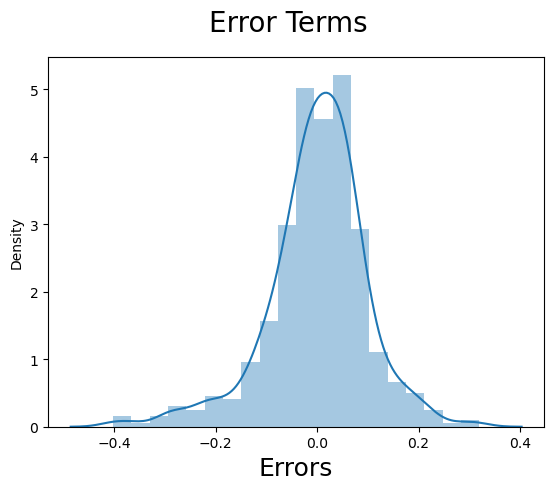

In [72]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)   

In [73]:

num_varlist = ["temp","atemp","hum","windspeed","cnt","instant"]

df_test[num_varlist] = scaler.transform(df_test[num_varlist])

In [74]:
df_test.describe()

,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,summer,winter,Light Snow,Mist,Monday,Saturday,Sunday,Thrusday,Tuesday,Wednesday
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,...,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,0.484682,0.453552,6.754098,0.049180,0.661202,0.536806,0.511633,0.642917,0.364411,0.504622,...,0.196721,0.284153,0.032787,0.355191,0.142077,0.147541,0.142077,0.147541,0.153005,0.153005
std,0.283437,0.499204,3.512876,0.216838,0.474600,0.236635,0.222128,0.147713,0.196694,0.229953,...,0.398610,0.452247,0.178567,0.479884,0.350086,0.355617,0.350086,0.355617,0.360980,0.360980
min,0.002743,0.000000,1.000000,0.000000,0.000000,0.060271,0.029650,0.193231,-0.049874,0.078578,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257888,0.000000,4.000000,0.000000,0.000000,0.332325,0.321477,0.522280,0.225835,0.316498,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.471879,0.000000,7.000000,0.000000,1.000000,0.553679,0.538428,0.638817,0.333305,0.509549,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.737311,1.000000,10.000000,0.000000,1.000000,0.744559,0.699636,0.728577,0.477065,0.684192,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.987654,1.000000,12.000000,1.000000,1.000000,0.984424,0.951946,0.997858,1.165056,0.963300,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [75]:
y_test = df_test.pop('cnt')
X_test = df_test

In [76]:
# Adding constant variable to test dataframe
X_test_sm = sm.add_constant(X_test)

In [77]:
X_test_sm = X_test_sm.drop(["instant", "mnth", "holiday","workingday", "atemp","spring", "Saturday" ,'Thrusday', 'Tuesday',
       'Wednesday'], axis = 1)

In [78]:
# Making predictions using the 

y_test_pred = lr_model.predict(X_test_sm)

### Model evoluation

Text(0, 0.5, 'y_pred')

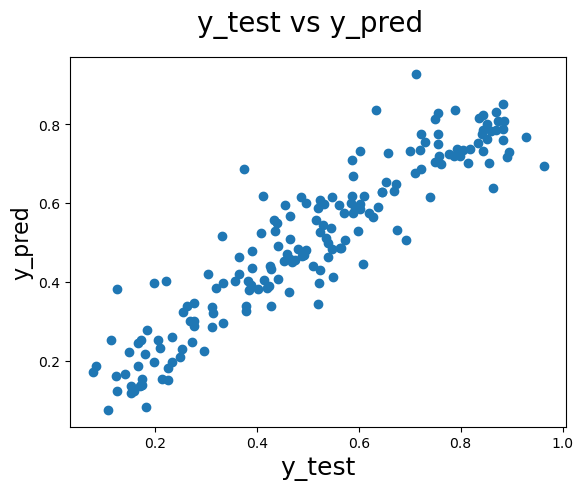

In [79]:
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_test, y_test_pred)
fig.suptitle('y_test vs y_pred', fontsize = 20)              # Plot heading 
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_pred', fontsize = 16)    

In [80]:
r2_score(y_true= y_test, y_pred=y_test_pred)

0.8553630466082778

### use RFE
Recursive feature elimination

In [81]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [82]:
df_train_rfe, df_test_rfe = train_test_split(bikes)

df_train_rfe.shape,df_test_rfe.shape,

((547, 21), (183, 21))

In [83]:
y_train = df_train_rfe.pop('cnt')
X_train = df_train_rfe

In [84]:
X_train.shape, y_train.shape

((547, 20), (547,))

In [85]:
# Running RFE with the output number of the variable equal to 10
lm = LinearRegression()
lm.fit(X_train, y_train)

# Initialize RFE with the LinearRegression model and specify the number of features to select
rfe = RFE(estimator=lm, n_features_to_select=15)

# Fit RFE on the training data
rfe = rfe.fit(X_train, y_train)

In [86]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('instant', False, 6),
 ('yr', True, 1),
 ('mnth', False, 5),
 ('holiday', True, 1),
 ('workingday', True, 1),
 ('temp', True, 1),
 ('atemp', False, 3),
 ('hum', False, 4),
 ('windspeed', False, 2),
 ('spring', True, 1),
 ('summer', True, 1),
 ('winter', True, 1),
 ('Light Snow', True, 1),
 ('Mist', True, 1),
 ('Monday', True, 1),
 ('Saturday', True, 1),
 ('Sunday', True, 1),
 ('Thrusday', True, 1),
 ('Tuesday', True, 1),
 ('Wednesday', True, 1)]

In [87]:
col = X_train.columns[rfe.support_]
col

Index(['yr', 'holiday', 'workingday', 'temp', 'spring', 'summer', 'winter',
       'Light Snow', 'Mist', 'Monday', 'Saturday', 'Sunday', 'Thrusday',
       'Tuesday', 'Wednesday'],
      dtype='object')

In [88]:
X_train.columns[~rfe.support_]

Index(['instant', 'mnth', 'atemp', 'hum', 'windspeed'], dtype='object')

### Building model using statsmodel, for the detailed statistics

In [89]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col]

In [90]:
# Adding a constant variable 

X_train_rfe = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_rfe).fit() 
#Let's see the summary of  linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     163.4
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          3.58e-182
Time:                        23:40:05   Log-Likelihood:                -4452.5
No. Observations:                 547   AIC:                             8935.
Df Residuals:                     532   BIC:                             9000.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        880.6939    216.782      4.063      0.0

In [91]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.0001
yr            0.0000
holiday       0.3263
workingday    0.0000
temp          0.0000
spring        0.0000
summer        0.0529
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Monday        0.0626
Saturday      0.0000
Sunday        0.5736
Thrusday      0.4872
Tuesday       0.1711
Wednesday     0.4965
dtype: object


In [92]:
X_train_rfe = X_train_rfe.drop(["Tuesday"], axis = 1)

In [93]:
# Adding a constant variable 
X_train_lm = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_lm).fit() 
#Let's see the summary of  linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     175.5
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          6.73e-183
Time:                        23:40:05   Log-Likelihood:                -4453.5
No. Observations:                 547   AIC:                             8935.
Df Residuals:                     533   BIC:                             8995.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        859.1146    216.388      3.970      0.0

In [94]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.0001
yr            0.0000
holiday       0.2195
workingday    0.0000
temp          0.0000
spring        0.0000
summer        0.0538
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Monday        0.1698
Saturday      0.0000
Sunday        0.3552
Thrusday      0.9978
Wednesday     0.9925
dtype: object


In [96]:
X_train_rfe.columns

Index(['const', 'yr', 'holiday', 'workingday', 'temp', 'spring', 'summer',
       'winter', 'Light Snow', 'Mist', 'Monday', 'Saturday', 'Sunday',
       'Thrusday', 'Wednesday'],
      dtype='object')

In [97]:
X_train_rfe = X_train_rfe.drop(["holiday"], axis = 1)

In [98]:
# Adding a constant variable 
X_train_lm = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_lm).fit() 
#Let's see the summary of  linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     175.5
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          6.73e-183
Time:                        23:45:13   Log-Likelihood:                -4453.5
No. Observations:                 547   AIC:                             8935.
Df Residuals:                     533   BIC:                             8995.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        616.1425    350.294      1.759      0.0

In [99]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.0792
yr            0.0000
workingday    0.0023
temp          0.0000
spring        0.0000
summer        0.0538
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Monday        0.1698
Saturday      0.0034
Sunday        0.1844
Thrusday      0.9978
Wednesday     0.9925
dtype: object


In [100]:
X_train_rfe = X_train_rfe.drop(["Wednesday"], axis = 1)
X_train_lm = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_lm).fit() 
#Let's see the summary of  linear model
print(lm.summary())



                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     190.5
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          4.77e-184
Time:                        23:45:57   Log-Likelihood:                -4453.5
No. Observations:                 547   AIC:                             8933.
Df Residuals:                     534   BIC:                             8989.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        615.8610    348.685      1.766      0.0

In [101]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.0779
yr            0.0000
workingday    0.0023
temp          0.0000
spring        0.0000
summer        0.0536
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Monday        0.1502
Saturday      0.0031
Sunday        0.1808
Thrusday      0.9998
dtype: object


In [102]:
X_train_rfe = X_train_rfe.drop(["Thrusday"], axis = 1)
X_train_lm = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_lm).fit() 
#Let's see the summary of  linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     208.2
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          3.23e-185
Time:                        23:46:26   Log-Likelihood:                -4453.5
No. Observations:                 547   AIC:                             8931.
Df Residuals:                     535   BIC:                             8983.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        615.8703    346.639      1.777      0.0

In [103]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.0762
yr            0.0000
workingday    0.0023
temp          0.0000
spring        0.0000
summer        0.0531
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Monday        0.1367
Saturday      0.0029
Sunday        0.1768
dtype: object


In [104]:
X_train_rfe = X_train_rfe.drop(["Monday"], axis = 1)
X_train_lm = sm.add_constant(X_train_rfe)
lm = sm.OLS(y_train,X_train_lm).fit() 
#Let's see the summary of  linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     228.2
Date:                Mon, 27 Jan 2025   Prob (F-statistic):          6.29e-186
Time:                        23:47:11   Log-Likelihood:                -4454.6
No. Observations:                 547   AIC:                             8931.
Df Residuals:                     536   BIC:                             8979.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        496.3224    337.615      1.470      0.1

In [105]:
p_values = lm.pvalues
formatted_pvalues = p_values.map(lambda x: f"{x:.4f}")

# Print the formatted p-values
print("P>|t| values:")
print(formatted_pvalues)

P>|t| values:
const         0.1421
yr            0.0000
workingday    0.0006
temp          0.0000
spring        0.0000
summer        0.0497
winter        0.0000
Light Snow    0.0000
Mist          0.0000
Saturday      0.0004
Sunday        0.0681
dtype: object


In [106]:
vif = pd.DataFrame()
X = X_train_rfe
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,88.09
2,workingday,8.62
10,Sunday,5.59
9,Saturday,5.52
4,spring,4.54
3,temp,3.25
6,winter,3.08
5,summer,1.95
8,Mist,1.05
7,Light Snow,1.04


### Residual Analysis of the train data

In [1]:
y_train_pred_rfe = lm.predict(X_train_lm)

NameError: name 'lm' is not defined

In [111]:
 = df_test_rfe.pop("cnt") 

KeyError: 'cnt'

In [112]:
r2_score(y_true= y_test_pre_rfe, y_pred=y_train_pred_rfe)

ValueError: Found input variables with inconsistent numbers of samples: [183, 547]